# ECO Load Decomposition
## Building Occupancy-Aware Components for the Simulation Engine

### Key findings from EDA that shape this notebook:
| House | Key characteristic | Treatment |
|---|---|---|
| H01 | Clean occupancy signal, moderate delta | Primary training house |
| H02 | Strongest occupancy delta (401W at 11h) | Best for occupancy modelling |
| H04 | Timer-driven boiler dominates (87% days) | Separate timer vs occ load |

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

DRIVE    = '/content/drive/MyDrive'
DATA_DIR = f'{DRIVE}/Colab_Notebooks/ECO_Dataset/eco_processed'
OUT_DIR  = f'{DRIVE}/eco_decomposed'

import os
os.makedirs(OUT_DIR, exist_ok=True)

# Load all three houses
houses = {}
for h in ['01', '02', '04']:
    df = pd.read_csv(f'{DATA_DIR}/house_{h}_1min.csv',
                     index_col=0, parse_dates=True)
    df['hour']      = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month']     = df.index.month
    df['is_weekend']= (df.index.dayofweek >= 5).astype(int)
    df['date']      = df.index.date
    houses[h] = df
    print(f'House {h}: {len(df):,} rows | {df.index.min().date()} → {df.index.max().date()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
House 01: 257,760 rows | 2012-07-15 → 2013-01-09
House 02: 328,320 rows | 2012-06-01 → 2013-01-15
House 04: 246,240 rows | 2012-07-25 → 2013-01-11


## 1. Three-Component Decomposition

```
Total Power = Baseline(t)  +  Timer(t)  +  OccupancyDelta(hour, occ)
                 ↓                ↓                  ↓
          always-on load   scheduled load    human-driven load
          (fridge, router) (boiler, H04)     (cooking, TV, etc.)
```

In [ ]:
def decompose(df, house_id, timer_hours=None, timer_threshold=None):
    """
    Decompose power into 3 components:
      1. baseline  : rolling daily minimum (always-on loads)
      2. timer     : scheduled spikes independent of occupancy
      3. occ_delta : per-hour difference driven by human presence

    Returns original df with extra columns + component tables.
    """
    result = df.copy()

    # ── Component 1: Baseline ──────────────────────────────────────────
    # 5th percentile of each day = always-on idle draw
    daily_p05 = df.groupby('date')['power_W'].transform(
        lambda x: np.percentile(x, 5)
    )
    result['baseline'] = daily_p05

    # ── Component 2: Timer load ────────────────────────────────────────
    # Hours where unoccupied mean > occupied mean (scheduled, not human)
    hourly = df.groupby(['hour','occupied'])['power_W'].mean().unstack()
    if 0 in hourly.columns and 1 in hourly.columns:
        timer_candidates = hourly[hourly[0] > hourly[1]].index.tolist()
    else:
        timer_candidates = []

    # Override with known timer hours if provided
    if timer_hours:
        timer_candidates = timer_hours

    # Timer component: power during timer hours, beyond baseline
    result['is_timer_hour'] = result['hour'].isin(timer_candidates).astype(int)
    result['timer'] = np.where(
        result['is_timer_hour'] == 1,
        np.maximum(result['power_W'] - result['baseline'], 0),
        0
    )

    # ── Component 3: Occupancy delta ──────────────────────────────────
    # Per-hour: mean_occupied - mean_unoccupied (clamped to >=0)
    if 0 in hourly.columns and 1 in hourly.columns:
        delta_table = (hourly[1] - hourly[0]).clip(lower=0)
    else:
        delta_table = pd.Series(0, index=range(24))

    result['occ_delta_max'] = result['hour'].map(delta_table)
    result['occ_delta']     = result['occ_delta_max'] * result['occupied']

    # ── Residual ──────────────────────────────────────────────────────
    result['residual'] = (
        result['power_W']
        - result['baseline']
        - result['timer']
        - result['occ_delta']
    ).clip(lower=0)

    # ── Component summary ─────────────────────────────────────────────
    total_mean = result['power_W'].mean()
    comp_means = {
        'baseline':  result['baseline'].mean(),
        'timer':     result['timer'].mean(),
        'occ_delta': result['occ_delta'].mean(),
        'residual':  result['residual'].mean(),
    }
    print(f'\nHouse {house_id} — decomposition (mean W):')
    print(f'  Total         : {total_mean:.1f} W')
    for k, v in comp_means.items():
        print(f'  {k:<12}: {v:.1f} W  ({v/total_mean*100:.1f}%)')
    print(f'  Timer hours   : {timer_candidates}')

    return result, delta_table


# H01 — timer hours: 6,7 (unoccupied > occupied slightly, morning routines)
h01, delta_01 = decompose(houses['01'], '01', timer_hours=[6, 7])

# H02 — no strong timer pattern
h02, delta_02 = decompose(houses['02'], '02', timer_hours=[])

# H04 — strong boiler at 3-4am (87% days, >2000W, independent of occupancy)
h04, delta_04 = decompose(houses['04'], '04', timer_hours=[2, 3, 4])


House 01 — decomposition (mean W):
  Total         : 284.7 W
  baseline    : 61.4 W  (21.5%)
  timer       : 16.8 W  (5.9%)
  occ_delta   : 26.1 W  (9.1%)
  residual    : 187.2 W  (65.8%)
  Timer hours   : [6, 7]

House 02 — decomposition (mean W):
  Total         : 210.1 W
  baseline    : 37.0 W  (17.6%)
  timer       : 9.8 W  (4.7%)
  occ_delta   : 34.3 W  (16.3%)
  residual    : 134.4 W  (64.0%)
  Timer hours   : [6, 23]

House 04 — decomposition (mean W):
  Total         : 887.7 W
  baseline    : 343.9 W  (38.7%)
  timer       : 204.8 W  (23.1%)
  occ_delta   : 14.0 W  (1.6%)
  residual    : 329.0 W  (37.1%)
  Timer hours   : [2, 3, 4]


## 2. Visualise Decomposition — All Houses

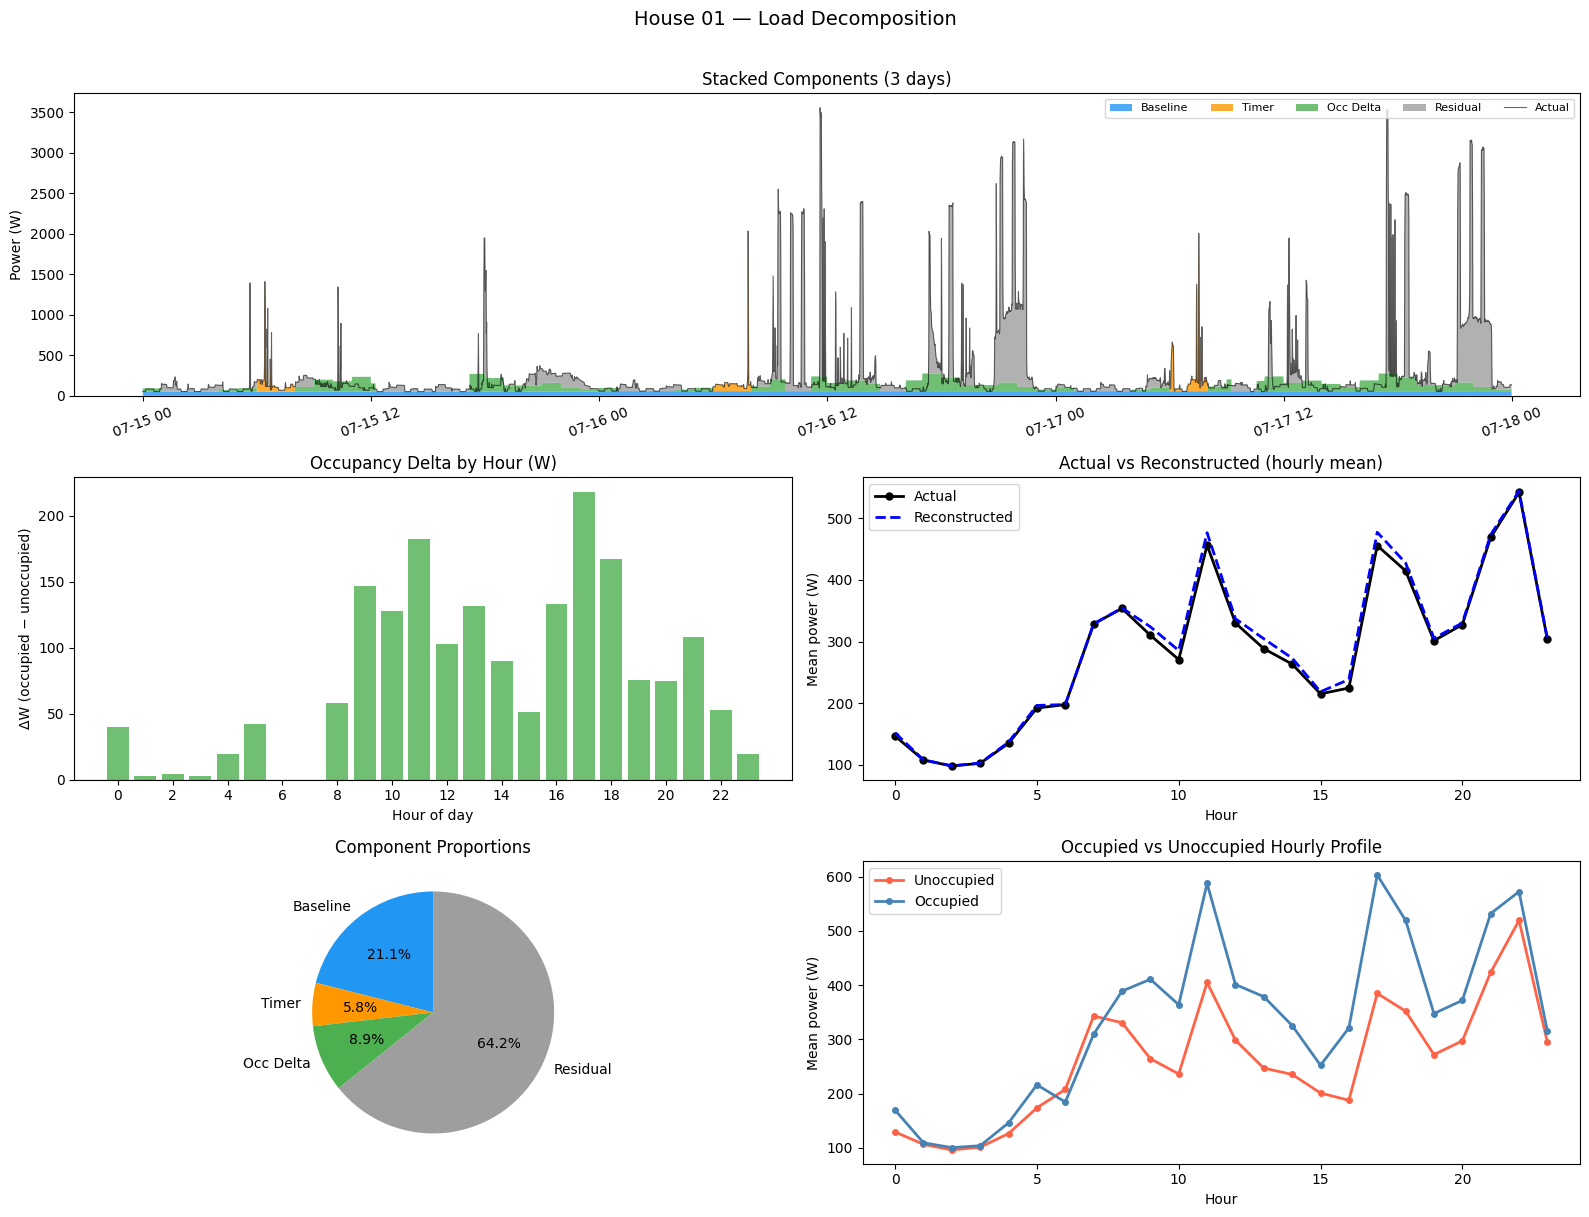

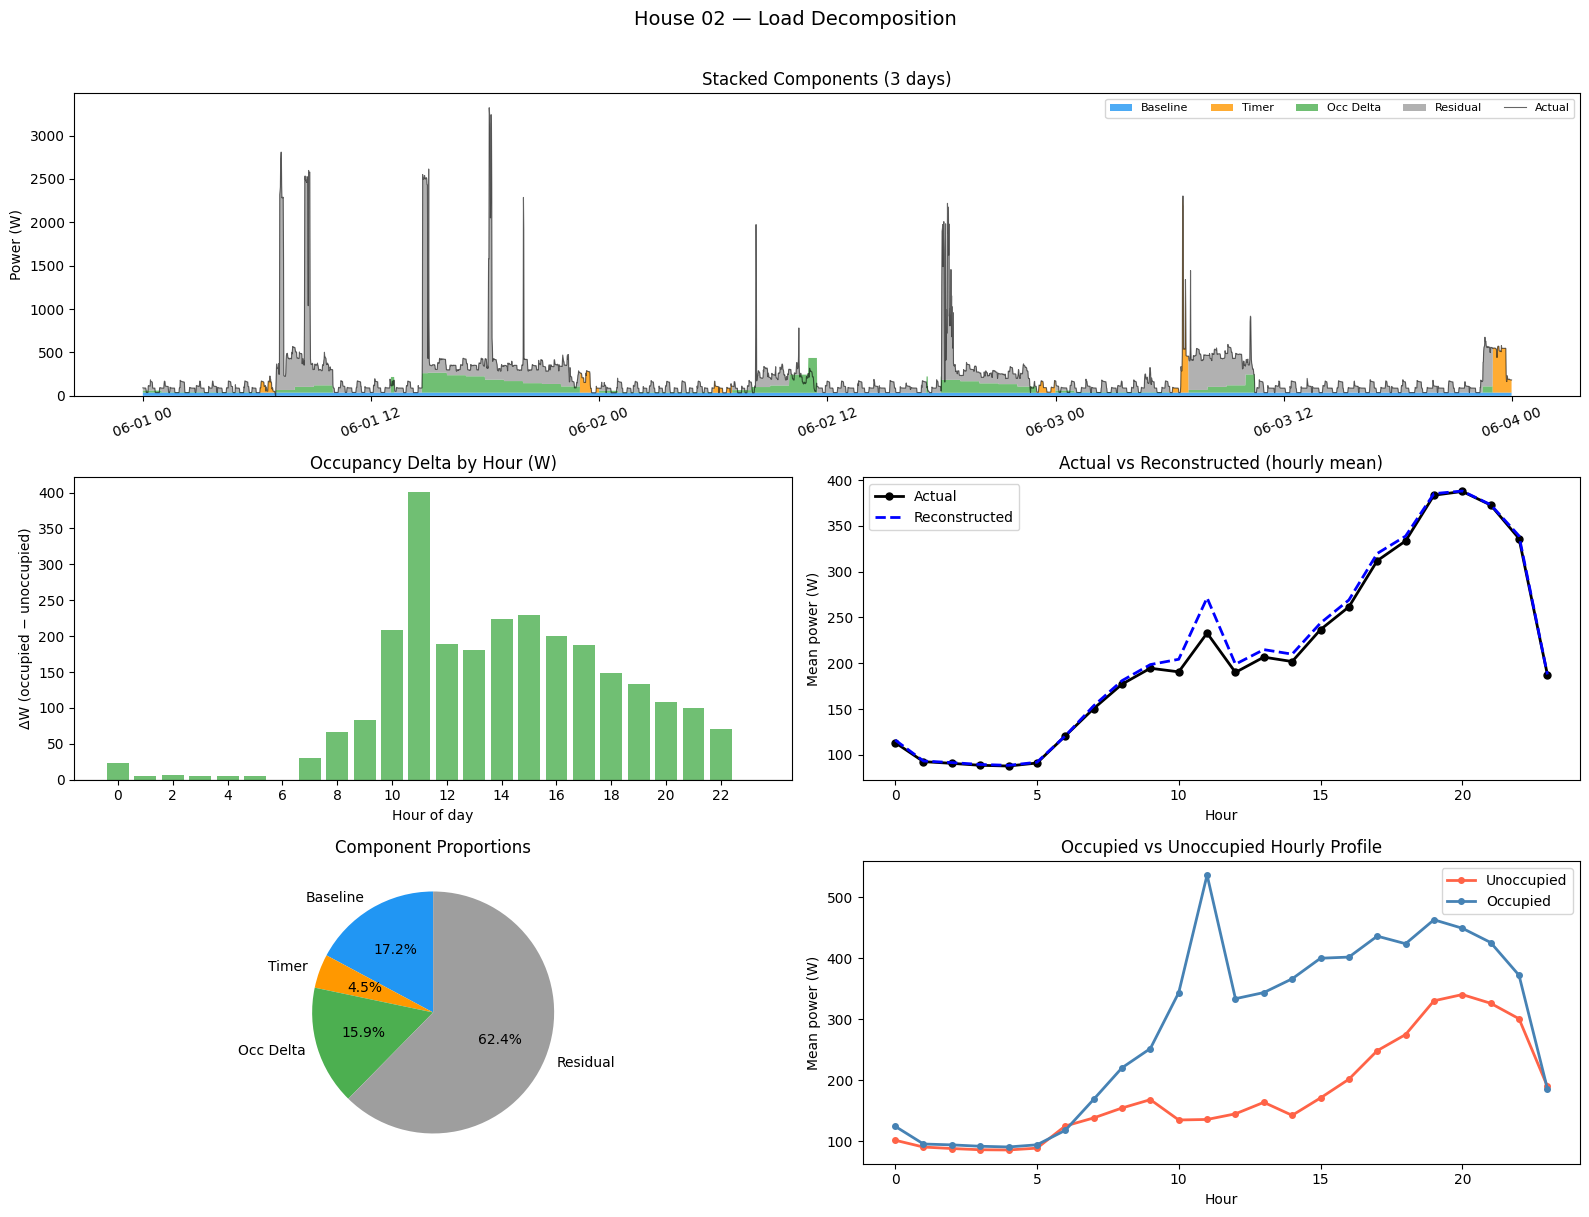

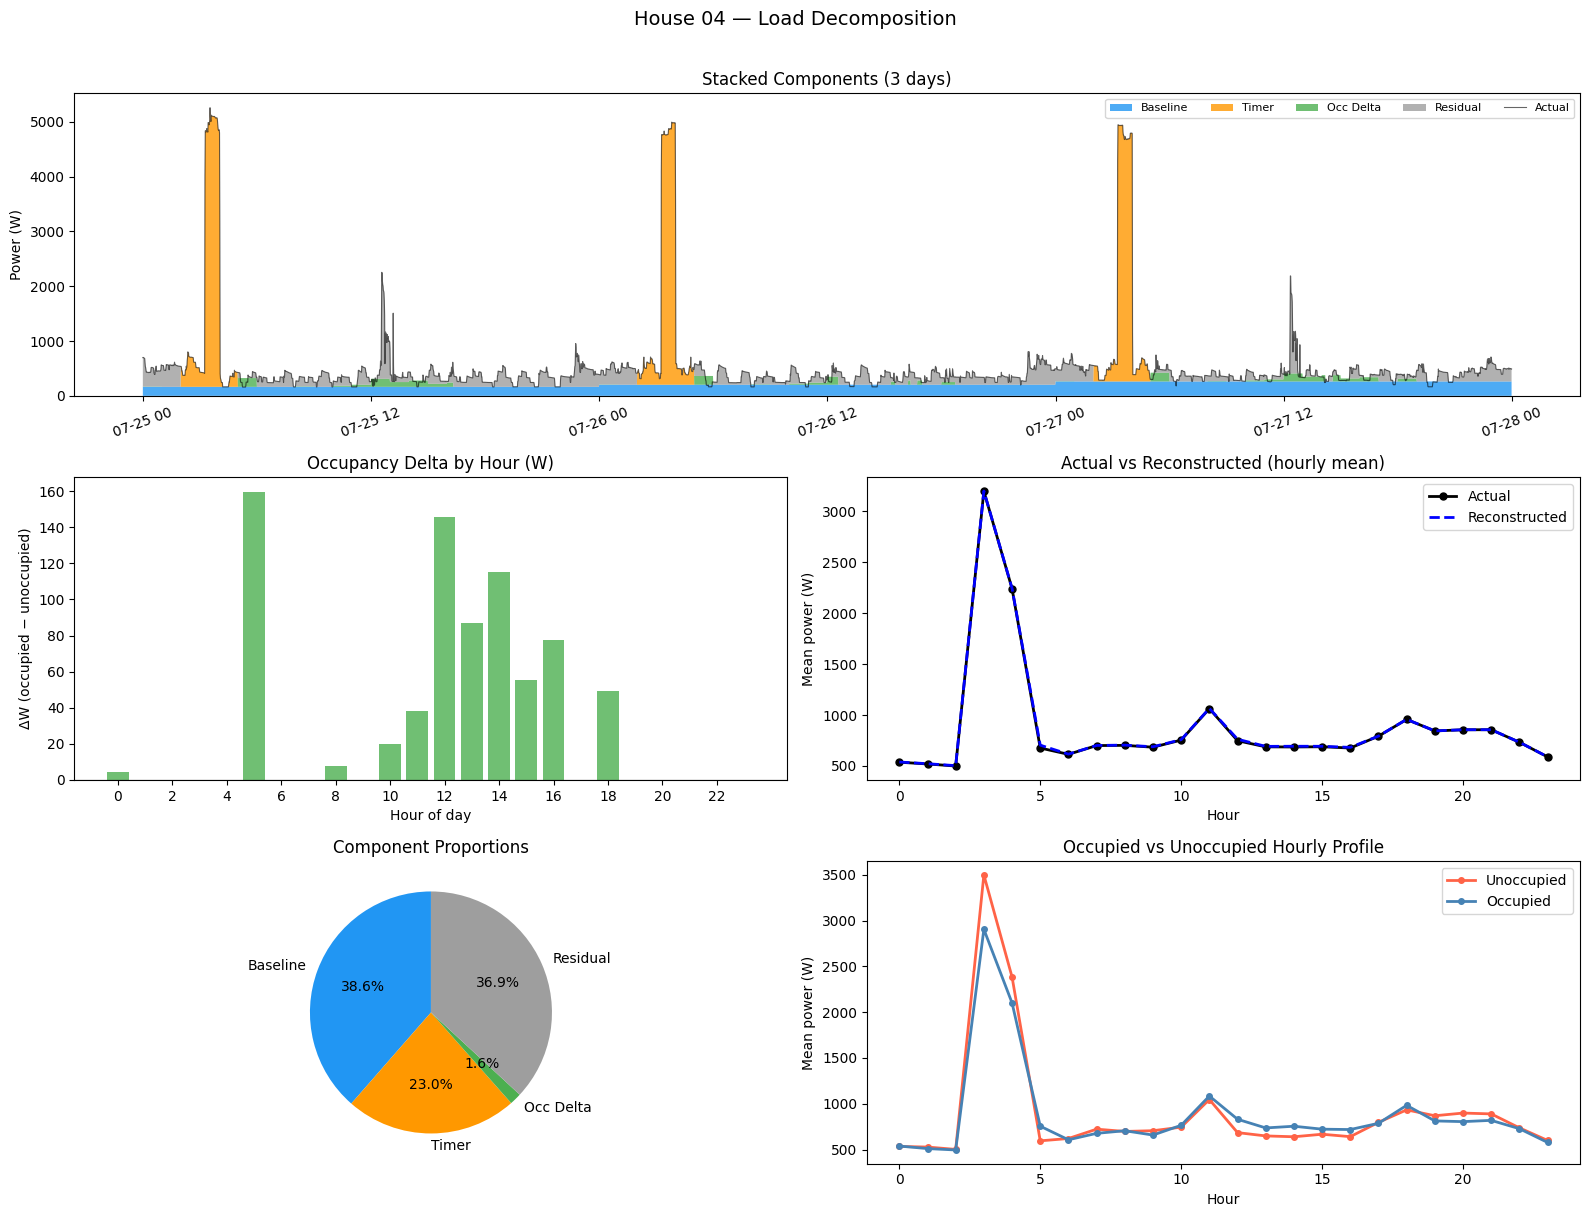

In [ ]:
def plot_decomposition(df, delta_table, house_id, n_days=3):
    fig = plt.figure(figsize=(16, 12))
    gs  = gridspec.GridSpec(3, 2, figure=fig)
    fig.suptitle(f'House {house_id} — Load Decomposition', fontsize=14, y=1.01)

    N = 60 * 24 * n_days
    sample = df.iloc[:N]

    # 1 — Stacked area: components over time
    ax1 = fig.add_subplot(gs[0, :])
    ax1.stackplot(
        sample.index,
        sample['baseline'],
        sample['timer'],
        sample['occ_delta'],
        sample['residual'],
        labels=['Baseline','Timer','Occ Delta','Residual'],
        colors=['#2196F3','#FF9800','#4CAF50','#9E9E9E'],
        alpha=0.8
    )
    ax1.plot(sample.index, sample['power_W'],
             'k-', lw=0.8, alpha=0.6, label='Actual')
    ax1.set_title(f'Stacked Components ({n_days} days)')
    ax1.set_ylabel('Power (W)')
    ax1.legend(loc='upper right', ncol=5, fontsize=8)
    ax1.tick_params(axis='x', rotation=20)

    # 2 — Per-hour occupancy delta
    ax2 = fig.add_subplot(gs[1, 0])
    colors = ['#F44336' if v < 0 else '#4CAF50' for v in delta_table]
    ax2.bar(delta_table.index, delta_table.values, color=colors, alpha=0.8)
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_title('Occupancy Delta by Hour (W)')
    ax2.set_xlabel('Hour of day')
    ax2.set_ylabel('ΔW (occupied − unoccupied)')
    ax2.set_xticks(range(0, 24, 2))

    # 3 — Mean hourly actual vs reconstructed
    ax3 = fig.add_subplot(gs[1, 1])
    df['reconstructed'] = (df['baseline'] + df['timer']
                           + df['occ_delta'] + df['residual'])
    hr_actual = df.groupby('hour')['power_W'].mean()
    hr_recon  = df.groupby('hour')['reconstructed'].mean()
    ax3.plot(hr_actual.index, hr_actual.values,
             'ko-', lw=2, ms=5, label='Actual')
    ax3.plot(hr_recon.index, hr_recon.values,
             'b--', lw=2, label='Reconstructed')
    ax3.set_title('Actual vs Reconstructed (hourly mean)')
    ax3.set_xlabel('Hour')
    ax3.set_ylabel('Mean power (W)')
    ax3.legend()

    # 4 — Component proportions (pie)
    ax4 = fig.add_subplot(gs[2, 0])
    comp_means = [
        df['baseline'].mean(),
        df['timer'].mean(),
        df['occ_delta'].mean(),
        df['residual'].mean(),
    ]
    labels = ['Baseline','Timer','Occ Delta','Residual']
    colors = ['#2196F3','#FF9800','#4CAF50','#9E9E9E']
    ax4.pie(comp_means, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
    ax4.set_title('Component Proportions')

    # 5 — Occupancy delta: occupied vs unoccupied profiles
    ax5 = fig.add_subplot(gs[2, 1])
    for occ_val, lbl, col in [(0,'Unoccupied','tomato'),(1,'Occupied','steelblue')]:
        profile = df[df.occupied==occ_val].groupby('hour')['power_W'].mean()
        ax5.plot(profile.index, profile.values,
                 color=col, lw=2, marker='o', ms=4, label=lbl)
    ax5.set_title('Occupied vs Unoccupied Hourly Profile')
    ax5.set_xlabel('Hour')
    ax5.set_ylabel('Mean power (W)')
    ax5.legend()

    plt.tight_layout()
    plt.savefig(f'/tmp/decomp_house{house_id}.png', dpi=120, bbox_inches='tight')
    plt.show()


plot_decomposition(h01, delta_01, '01')
plot_decomposition(h02, delta_02, '02')
plot_decomposition(h04, delta_04, '04')

## 3. Build Transferable Occupancy Delta Tables

In [ ]:
def build_delta_table(df, house_id):
    """
    Build a rich per-hour occupancy delta table with:
    - weekday vs weekend splits
    - confidence (how many observations back each estimate)
    - normalized delta (% of unoccupied baseline) for transferability
    """
    results = []

    for is_weekend in [0, 1]:
        sub = df[df.is_weekend == is_weekend]
        hourly = sub.groupby(['hour','occupied'])['power_W'].agg(['mean','count']).unstack()

        for hour in range(24):
            try:
                mean_occ   = hourly['mean'][1][hour]
                mean_unocc = hourly['mean'][0][hour]
                n_occ      = hourly['count'][1][hour]
                n_unocc    = hourly['count'][0][hour]
            except (KeyError, IndexError):
                continue

            delta_W   = max(mean_occ - mean_unocc, 0)  # clamp negatives
            delta_pct = (delta_W / mean_unocc * 100) if mean_unocc > 0 else 0

            results.append({
                'house':        house_id,
                'is_weekend':   is_weekend,
                'hour':         hour,
                'mean_occ_W':   round(mean_occ, 1),
                'mean_unocc_W': round(mean_unocc, 1),
                'delta_W':      round(delta_W, 1),
                'delta_pct':    round(delta_pct, 1),
                'n_occ':        int(n_occ),
                'n_unocc':      int(n_unocc),
                'reliable':     (n_occ >= 100) and (n_unocc >= 100),
            })

    return pd.DataFrame(results)


delta_tables = {}
for h, df in [('01',h01), ('02',h02), ('04',h04)]:
    dt = build_delta_table(df, h)
    delta_tables[h] = dt
    reliable_pct = dt['reliable'].mean() * 100
    print(f'House {h}: {len(dt)} hour-entries | {reliable_pct:.0f}% reliable')

# Combine all houses
all_deltas = pd.concat(delta_tables.values(), ignore_index=True)

# Cross-house average delta (normalised, for simulation transfer)
cross_house_delta = all_deltas[
    (all_deltas['reliable']) & (all_deltas['house'] != '04')  # exclude H04 boiler
].groupby(['hour','is_weekend']).agg(
    delta_W_mean  = ('delta_W',   'mean'),
    delta_pct_mean= ('delta_pct', 'mean'),
    n_houses      = ('house',     'nunique')
).round(1).reset_index()

print('\nCross-house delta table (H01+H02, weekday):')
weekday = cross_house_delta[cross_house_delta.is_weekend==0]
print(weekday[['hour','delta_W_mean','delta_pct_mean']].to_string(index=False))

House 01: 48 hour-entries | 100% reliable
House 02: 48 hour-entries | 100% reliable
House 04: 48 hour-entries | 100% reliable

Cross-house delta table (H01+H02, weekday):
 hour  delta_W_mean  delta_pct_mean
    0          20.4            19.5
    1           6.2             6.8
    2           5.4             5.9
    3           5.1             6.0
    4          12.7            11.0
    5          16.8            10.8
    6           0.0             0.0
    7          28.6            19.8
    8          71.1            34.8
    9         128.3            62.7
   10         186.2           125.4
   11         315.2           207.4
   12         172.6           100.8
   13         165.8            93.5
   14         179.2           116.5
   15         165.0           106.2
   16         171.9            95.6
   17         184.0            65.5
   18          95.3            31.6
   19          82.5            27.6
   20          84.9            26.8
   21         106.0            30.2
 

## 4. Override Layer — Simulation Functions

In [ ]:
class OccupancySimulator:
    """
    Simulation engine that adjusts a base load forecast
    using decomposed occupancy-aware components.

    Inputs:
      base_profile  : 24-element array of baseline hourly power (W)
      delta_table   : DataFrame with columns [hour, is_weekend, delta_W_mean]
      house_baseline: float, mean idle power of target house (W)

    Override parameters (all optional):
      n_people      : number of occupants (default=2)
      is_vacation   : bool, forces occupancy=0
      guests        : int, extra visitors
      is_weekend    : bool
      outdoor_temp  : float (°C), adjusts HVAC estimate
    """

    def __init__(self, delta_table, house_baseline=150.0,
                 default_occupants=2):
        self.delta_table       = delta_table
        self.house_baseline    = house_baseline
        self.default_occupants = default_occupants

    def _get_delta(self, hour, is_weekend):
        row = self.delta_table[
            (self.delta_table.hour == hour) &
            (self.delta_table.is_weekend == int(is_weekend))
        ]
        return float(row['delta_W_mean'].values[0]) if len(row) else 0.0

    def _hvac_adjustment(self, outdoor_temp):
        """
        Simple thermal model:
        Below 15°C: heating load increases
        Above 25°C: cooling load increases
        """
        if outdoor_temp is None:
            return np.zeros(24)
        hvac = np.zeros(24)
        if outdoor_temp < 15:
            # Heating: ramps up in evening (17-22h)
            heat_load = (15 - outdoor_temp) * 12  # ~12W per degree
            hvac[17:22] += heat_load
            hvac[6:9]   += heat_load * 0.5
        elif outdoor_temp > 25:
            # Cooling: flat daytime load
            cool_load = (outdoor_temp - 25) * 8
            hvac[10:22] += cool_load
        return hvac

    def predict(self,
                base_profile,
                n_people     = 2,
                is_vacation  = False,
                guests       = 0,
                is_weekend   = False,
                outdoor_temp = None,
                solar_gen    = None):
        """
        Returns dict with 24-element arrays for each output component.
        """
        base = np.array(base_profile, dtype=float)
        hours = np.arange(24)

        # ── Occupancy probability per hour ────────────────────────────
        if is_vacation:
            occ_prob = np.zeros(24)     # nobody home
        else:
            # Scale by number of people (relative to default)
            total_people = n_people + guests
            occ_scale    = min(total_people / self.default_occupants, 2.0)
            # Typical presence pattern: low at night, high evening
            # (learned from ECO transitions — mean arrival 17h, departure 9h)
            base_occ = np.array([
                0.9,0.9,0.9,0.9,0.9,0.8,  # 0-5: sleeping/early
                0.6,0.4,0.3,0.2,0.2,0.2,  # 6-11: leaving for work
                0.2,0.2,0.2,0.3,0.4,0.7,  # 12-17: daytime out
                0.8,0.9,0.9,0.9,0.9,0.9,  # 18-23: home evening
            ])
            if is_weekend:
                base_occ = np.clip(base_occ * 1.3, 0, 1)  # more home on weekends
            occ_prob = np.clip(base_occ * occ_scale, 0, 1)

        # ── Occupancy delta component ──────────────────────────────────
        occ_delta = np.array([
            self._get_delta(h, is_weekend) * occ_prob[h]
            for h in hours
        ])

        # ── HVAC adjustment ───────────────────────────────────────────
        hvac = self._hvac_adjustment(outdoor_temp)

        # ── Final forecast ────────────────────────────────────────────
        gross_load = base + occ_delta + hvac
        gross_load = np.clip(gross_load, 0, None)

        # ── Net load (with solar if provided) ─────────────────────────
        solar      = np.array(solar_gen) if solar_gen else np.zeros(24)
        net_load   = gross_load - solar

        return {
            'hour':        hours,
            'base':        base,
            'occ_delta':   occ_delta,
            'hvac':        hvac,
            'gross_load':  gross_load,
            'solar':       solar,
            'net_load':    net_load,
            'grid_import': np.maximum(net_load, 0),
            'grid_export': np.maximum(-net_load, 0),
            'occ_prob':    occ_prob,
        }


# Instantiate simulator using H01+H02 cross-house delta table
sim = OccupancySimulator(
    delta_table       = cross_house_delta,
    house_baseline    = 150.0,
    default_occupants = 2
)

# Base profile: H02 mean hourly power as reference forecast
base_profile = h02.groupby('hour')['power_W'].mean().values

print('Simulator ready.')
print(f'Base profile (mean W per hour): {base_profile.round(0).astype(int).tolist()}')

Simulator ready.
Base profile (mean W per hour): [114, 93, 91, 89, 88, 91, 121, 151, 177, 195, 191, 233, 190, 207, 202, 237, 262, 312, 334, 383, 388, 373, 336, 188]


## 5. What-If Scenario Comparison

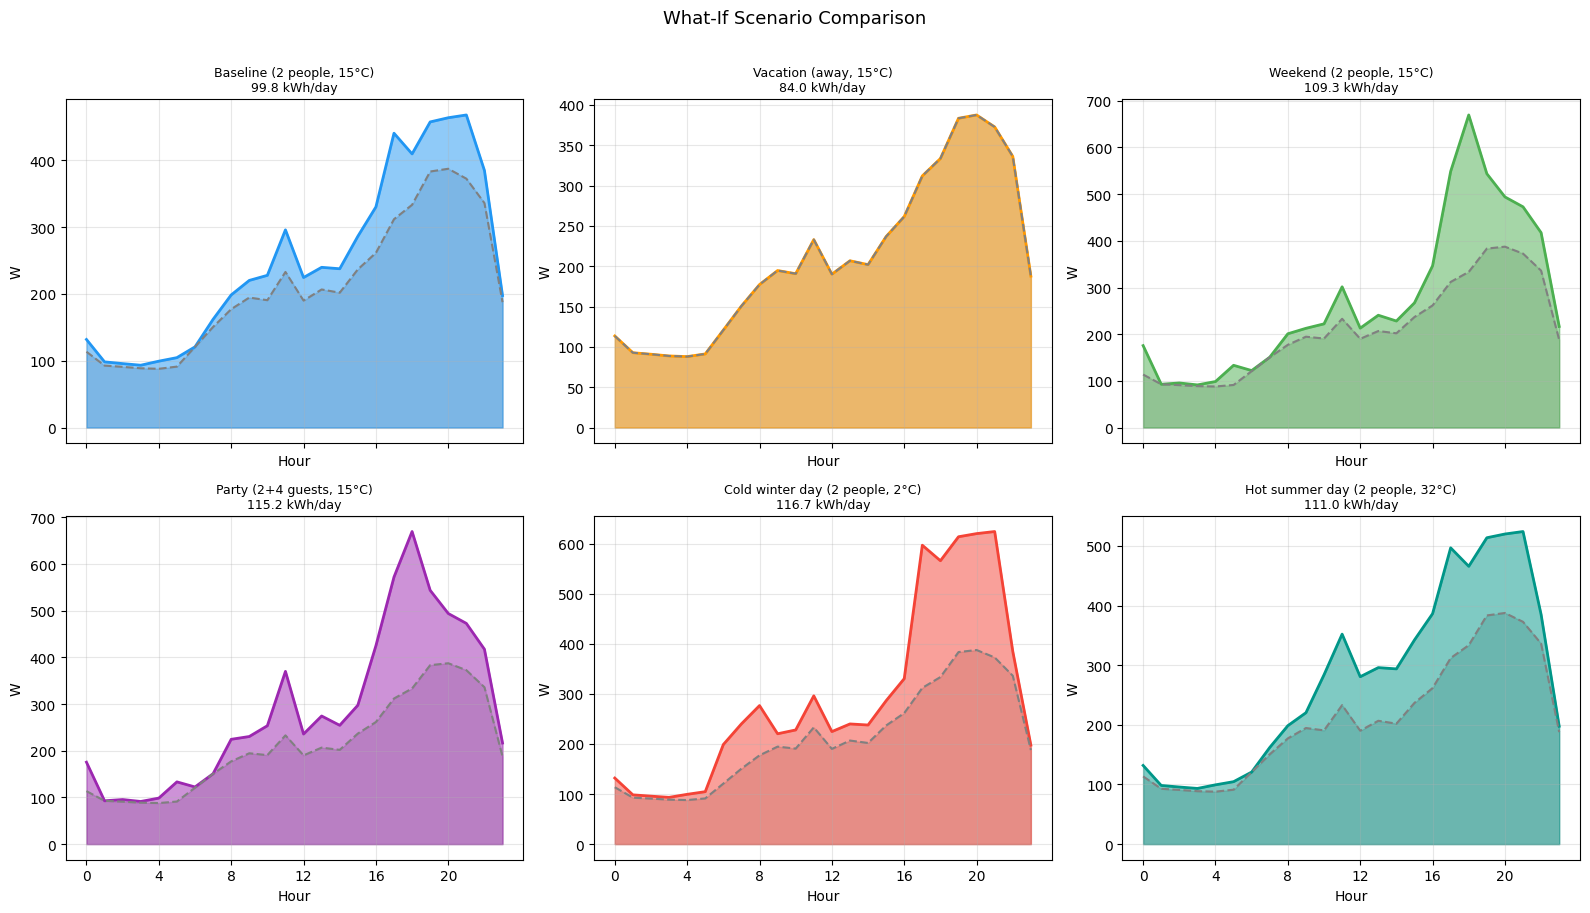


=== Scenario Summary ===
Scenario                                  Daily kWh   Peak W  vs Baseline
--------------------------------------------------------------------------
Baseline (2 people, 15°C)                     99.84      468 +      0.00 kWh
Vacation (away, 15°C)                         84.03      388     -15.81 kWh
Weekend (2 people, 15°C)                     109.26      670 +      9.42 kWh
Party (2+4 guests, 15°C)                     115.21      670 +     15.37 kWh
Cold winter day (2 people, 2°C)              116.74      624 +     16.90 kWh
Hot summer day (2 people, 32°C)              111.04      524 +     11.20 kWh


In [ ]:
# Define 6 scenarios that test every override parameter
scenarios = {
    'Baseline (2 people, 15°C)': dict(
        n_people=2, is_vacation=False, guests=0,
        is_weekend=False, outdoor_temp=15),

    'Vacation (away, 15°C)': dict(
        n_people=2, is_vacation=True, guests=0,
        is_weekend=False, outdoor_temp=15),

    'Weekend (2 people, 15°C)': dict(
        n_people=2, is_vacation=False, guests=0,
        is_weekend=True, outdoor_temp=15),

    'Party (2+4 guests, 15°C)': dict(
        n_people=2, is_vacation=False, guests=4,
        is_weekend=True, outdoor_temp=15),

    'Cold winter day (2 people, 2°C)': dict(
        n_people=2, is_vacation=False, guests=0,
        is_weekend=False, outdoor_temp=2),

    'Hot summer day (2 people, 32°C)': dict(
        n_people=2, is_vacation=False, guests=0,
        is_weekend=False, outdoor_temp=32),
}

# Run all scenarios
results = {}
for name, params in scenarios.items():
    results[name] = sim.predict(base_profile, **params)

# Plot
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.flatten()
colors = ['#2196F3','#FF9800','#4CAF50','#9C27B0','#F44336','#009688']

for ax, (name, res), col in zip(axes, results.items(), colors):
    hours = res['hour']
    ax.fill_between(hours, res['base'],        alpha=0.3, color='grey',  label='Base')
    ax.fill_between(hours, res['gross_load'],  alpha=0.5, color=col,     label='Gross load')
    ax.plot(hours, res['gross_load'], color=col, lw=2)
    ax.plot(hours, res['base'],      color='grey', lw=1.5, linestyle='--')
    daily_kwh = res['gross_load'].sum() / 60
    ax.set_title(f'{name}\n{daily_kwh:.1f} kWh/day', fontsize=9)
    ax.set_xlabel('Hour')
    ax.set_ylabel('W')
    ax.set_xticks(range(0,24,4))
    ax.grid(alpha=0.3)

plt.suptitle('What-If Scenario Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/eco_scenarios.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary table
print('\n=== Scenario Summary ===')
print(f'{"Scenario":<40} {"Daily kWh":>10} {"Peak W":>8} {"vs Baseline":>12}')
print('-' * 74)
base_kwh = results['Baseline (2 people, 15°C)']['gross_load'].sum() / 60
for name, res in results.items():
    kwh  = res['gross_load'].sum() / 60
    peak = res['gross_load'].max()
    diff = kwh - base_kwh
    sign = '+' if diff >= 0 else ''
    print(f'{name:<40} {kwh:>10.2f} {peak:>8.0f} {sign}{diff:>10.2f} kWh')

## 6. Save Artefacts for Next Module

In [ ]:
# Save delta tables
all_deltas.to_csv(f'{OUT_DIR}/all_houses_delta_table.csv', index=False)
cross_house_delta.to_csv(f'{OUT_DIR}/cross_house_delta_table.csv', index=False)

# Save decomposed house data
for h, df in [('01',h01),('02',h02),('04',h04)]:
    df.drop(columns=['date'], errors='ignore').to_csv(
        f'{OUT_DIR}/house_{h}_decomposed.csv'
    )

# Save base profiles (mean hourly W per house)
base_profiles = {}
for h, df in [('01',h01),('02',h02),('04',h04)]:
    base_profiles[f'house_{h}'] = df.groupby('hour')['power_W'].mean().values.round(1)
pd.DataFrame(base_profiles, index=range(24)).to_csv(
    f'{OUT_DIR}/base_profiles.csv'
)

print('Saved to:', OUT_DIR)
print('Files:')
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(f'{OUT_DIR}/{f}')
    print(f'  {f}  ({size/1024:.0f} KB)')

print('\n✓ Ready for Phase 2: LSTM load forecasting module')

Saved to: /content/drive/MyDrive/eco_decomposed
Files:
  all_houses_delta_table.csv  (6 KB)
  base_profiles.csv  (1 KB)
  cross_house_delta_table.csv  (1 KB)
  house_01_decomposed.csv  (32434 KB)
  house_02_decomposed.csv  (41362 KB)
  house_04_decomposed.csv  (29336 KB)

✓ Ready for Phase 2: LSTM load forecasting module
